# TON-IOT Anomaly Detection Pipeline
## SVM Training with Resource Monitoring

This notebook implements a complete machine learning pipeline for network intrusion detection:
- **Data Loading & Splitting** (70/15/15 stratified)
- **Feature Engineering & Preprocessing**
- **SVM Training**: 3 Models: SVC, LinearSVC, SGDClassifier
- **Model Evaluation** with F2-score (security-focused)
- **Resource Monitoring** (CPU, Memory, Energy)

## 1. Setup & Imports

In [1]:
# Import required modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# Import custom pipeline functions
from ton_iot_pipeline import load_and_split_data, preprocess_data, train_svm, evaluate_model
from ton_iot_utils import print_system_info

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Configuration

In [2]:
# Pipeline configuration
CONFIG = {
    'dataset_path': 'data/train_test_network.csv',
    'enable_monitoring': True,  # Track CPU, memory, energy
    'save_models': True,  # Save trained models
    'random_state': 42
}

TRAINING_MODES = ['svc', 'linearsvc', 'sgd']

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nTraining modes: {TRAINING_MODES}")

Configuration:
  dataset_path: data/train_test_network.csv
  enable_monitoring: True
  save_models: True
  random_state: 42

Training modes: ['svc', 'linearsvc', 'sgd']


## 3. Data Loading & Splitting

Load the TON-IOT dataset and perform stratified split:
- **70%** Training (for model training)
- **15%** Validation (for hyperparameter tuning & development)
- **15%** Test (held out, untouched until final evaluation)

In [3]:
# Load and split data
print("="*70)
print("DATA LOADING & SPLITTING")
print("="*70)

X_train, X_val, X_test, y_train, y_val, y_test, strat_train, strat_val, strat_test = load_and_split_data(
    filepath=CONFIG['dataset_path'],
    random_state=CONFIG['random_state']
)

print("\n Data split complete")
print(f"  Training samples: {len(X_train):,}")
print(f"  Validation samples: {len(X_val):,}")
print(f"  Test samples: {len(X_test):,} (untouched during development)")

DATA LOADING & SPLITTING
Loading dataset...
Dataset shape: (211043, 44)
Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Data split (stratified by attack type):
  Train: 147,730 samples (70.0%)
  Val:   31,656 samples (15.0%)
  Test:  31,657 samples (15.0%)

Label distribution (0=normal, 1=attack):
  Train: 76.31% attacks
  Val:   76.31% attacks
  Test:  76.31% attacks

 Data split complete
  

### 3.1 Visualize Class Distribution

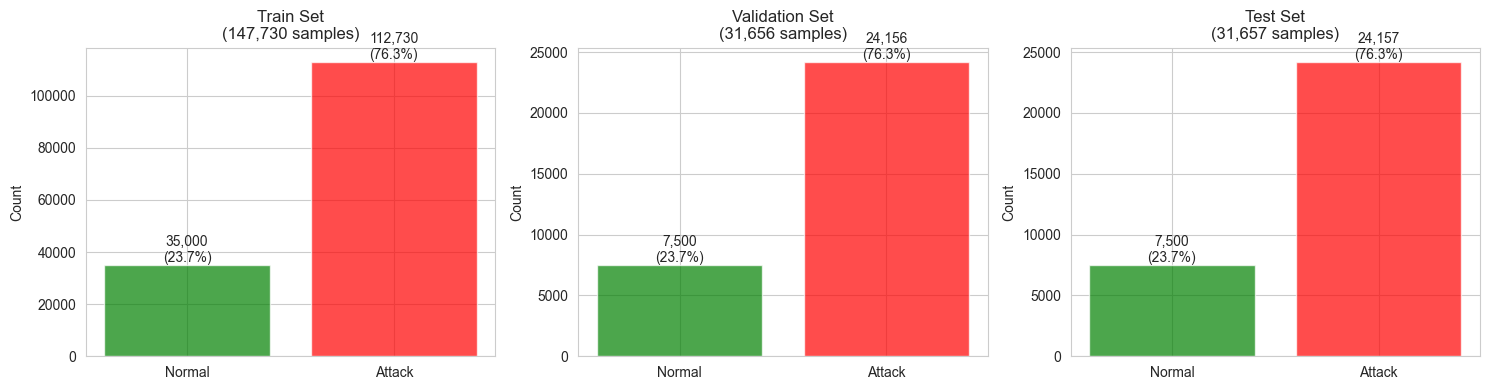

Attack rate: Train=76.31%, Val=76.31%, Test=76.31%


In [6]:
# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (y_data, title) in zip(axes, [(y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')]):
    counts = y_data.value_counts().sort_index()
    ax.bar(['Normal', 'Attack'], counts.values, color=['green', 'red'], alpha=0.7)
    ax.set_title(f'{title} Set\n({len(y_data):,} samples)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v:,}\n({v/len(y_data)*100:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Attack rate: Train={y_train.mean()*100:.2f}%, Val={y_val.mean()*100:.2f}%, Test={y_test.mean()*100:.2f}%")

### 3.2 Attack Type Distribution


Attack Type Distribution:

Training Set:
type
normal        0.2369
ddos          0.0948
scanning      0.0948
injection     0.0948
password      0.0948
ransomware    0.0948
xss           0.0948
backdoor      0.0948
dos           0.0948
mitm          0.0049
Name: proportion, dtype: float64

Validation Set:
type
normal        0.2369
injection     0.0948
xss           0.0948
ransomware    0.0948
password      0.0948
scanning      0.0948
backdoor      0.0948
ddos          0.0948
dos           0.0948
mitm          0.0049
Name: proportion, dtype: float64


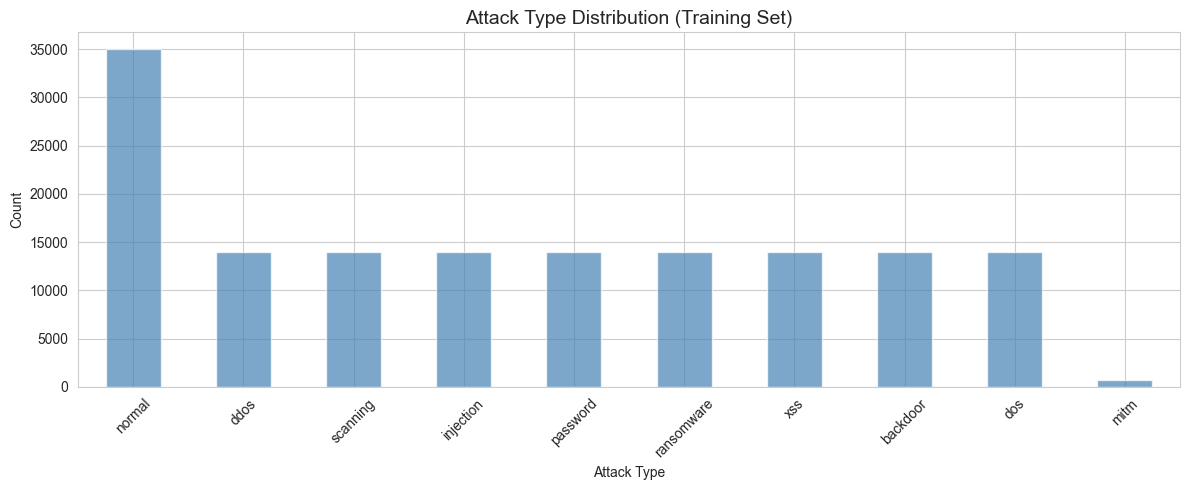

In [5]:
# Show attack type distribution
print("\nAttack Type Distribution:")
print("\nTraining Set:")
print(strat_train.value_counts(normalize=True).round(4))

print("\nValidation Set:")
print(strat_val.value_counts(normalize=True).round(4))

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
strat_train.value_counts().plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title('Attack Type Distribution (Training Set)', fontsize=14)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Preprocessing

Apply feature engineering and preprocessing:
- **Feature Elimination**: Remove IPs and ports
- **Imputation**: Context-aware handling of missing values
- **Scaling**: RobustScaler for continuous features
- **Encoding**: OneHotEncoding + Binary presence encoding (0 if missing, 1 if present)

In [6]:
# Preprocess data (fit on train, transform train and val)
preprocessing_pipeline, X_train_processed, X_val_processed, _ = preprocess_data(
    X_train=X_train,
    X_val=X_val,
    X_test=None,  # Keep test untouched
)

print("\n Preprocessing complete")
print(f"  Features before: {X_train.shape[1]}")
print(f"  Features after: {X_train_processed.shape[1]}")


PREPROCESSING

Fitting pipeline on training data...
Transforming validation data...

Processed dimensions:
  Training:   (147730, 79)
  Validation: (31656, 79)
  Total features: 79

 Preprocessing complete
  Features before: 42
  Features after: 79


### 4.1 Feature Names

In [7]:
# Get processed feature names
feature_names = preprocessing_pipeline.named_steps['preprocess'].get_feature_names_out()

print(f"Total features after preprocessing: {len(feature_names)}")
print("\nFirst 20 features:")
for i, name in enumerate(feature_names[:20], 1):
    print(f"  {i:2d}. {name}")

if len(feature_names) > 20:
    print(f"  ... and {len(feature_names) - 20} more")

Total features after preprocessing: 79

First 20 features:
   1. scaler__duration
   2. scaler__src_bytes
   3. scaler__dst_bytes
   4. scaler__missed_bytes
   5. scaler__src_pkts
   6. scaler__src_ip_bytes
   7. scaler__dst_pkts
   8. scaler__dst_ip_bytes
   9. scaler__http_request_body_len
  10. scaler__http_response_body_len
  11. scaler__http_trans_depth
  12. ohe__proto_tcp
  13. ohe__proto_udp
  14. ohe__service_dce_rpc
  15. ohe__service_dns
  16. ohe__service_ftp
  17. ohe__service_gssapi
  18. ohe__service_http
  19. ohe__service_smb
  20. ohe__service_smb;gssapi
  ... and 59 more


## 5. Model Training

Train all three models with Resource monitoring (time, CPU, memory, energy).
In the case of LinearSVC and SGD with:
- **5-fold Cross-Validation** on training data
- **Optuna** for hyperparameter tuning
- **F2-score optimization in CV** (prioritizes recall for security)

In [8]:
print_system_info()


Operating System:
  Platform: Windows 11
  Version:  10.0.26200
  Machine:  AMD64
  Processor: AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD

CPU:
  Physical cores: 8
  Logical cores:  16
  CPU frequency:  4700.00 MHz

Memory:
  Total RAM: 61.6 GB
  Available RAM: 51.3 GB

Python:
  Version: 3.13.7


In [9]:
# Storage for results
trained_models = {}
training_stats_all = {}
model_files = {}

print("\n" + "="*70)
print("TRAINING ALL MODELS")
print("="*70)
print(f"Training {len(TRAINING_MODES)} models sequentially...\n")

for i, mode in enumerate(TRAINING_MODES, 1):
    print(f"\n{'='*70}")
    print(f"MODEL {i}/{len(TRAINING_MODES)}: {mode.upper()}")
    print("="*70)
    
    # Train model
    model, training_stats = train_svm(
        X_train=X_train_processed,
        y_train=y_train,
        mode=mode,
        monitor=CONFIG['enable_monitoring']
    )
    
    # Store results
    trained_models[mode] = model
    training_stats_all[mode] = training_stats
    
    print(f"\n {mode.upper()} training complete")

print("\n" + "="*70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("="*70)

[codecarbon WARNING @ 11:27:01] Multiple instances of codecarbon are allowed to run at the same time.



TRAINING ALL MODELS
Training 3 models sequentially...


MODEL 1/3: SVC

TRAINING SVM
Resource monitoring started for: SVM Training

 Mode: SVC with Optuna (RBF Kernel)
   - Non-linear kernel (can capture complex patterns)
   - SLOW on large datasets but potentially better accuracy
   - Optuna optimization: 200 trials, 5-fold CV
   - Timeout: 3600s
   - Intelligent hyperparameter search (TPE sampler)

 Starting Optuna optimization...

   Completed 3 trials
Resource monitoring stopped for: SVM Training

RESOURCE USAGE - SVM Training
Time:
  Wall time:     5531.38 seconds
  Process time:  1014.19 seconds (isolated CPU time)
  I/O wait:      4517.19 seconds

Memory:
  Peak:  94.66 MB

CPU:
  Average: 29.7%
  Peak:    57.6%
  Samples: 2764

Energy:
  Consumption: 0.606642 kWh
  CO2 emissions: 0.606642 kg


----------------------------------------------------------------------
 Best parameters: {'C': 6.2513735745217485, 'gamma': 'scale'}
 Best CV F2-score: 0.9416
 Trials completed: 3/200
 (

c:\studium\master\semester1\machine-learning\venv-mal\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Resource monitoring stopped for: SVM Training

RESOURCE USAGE - SVM Training
Time:
  Wall time:     3617.47 seconds
  Process time:  56.12 seconds (isolated CPU time)
  I/O wait:      3561.34 seconds

Memory:
  Peak:  23.78 MB

CPU:
  Average: 29.6%
  Peak:    49.4%
  Samples: 1808

Energy:
  Consumption: 0.387975 kWh
  CO2 emissions: 0.387975 kg


----------------------------------------------------------------------
 Best parameters: {'C': 0.002804138824696653, 'loss': 'hinge'}
 Best CV F2-score: 0.9803
 Trials completed: 161/200
 (Stopped early due to timeout)
----------------------------------------------------------------------

 LINEARSVC training complete

MODEL 3/3: SGD

TRAINING SVM
Resource monitoring started for: SVM Training

 Mode: SGDClassifier with Optuna
   - Stochastic Gradient Descent (fast, requires more tuning)
   - Scales well to large datasets
   - Optuna optimization: 200 trials, 5-fold CV
   - Intelligent hyperparameter search (TPE sampler)

 Starting Optuna opt

## 6. Model Evaluation

Evaluate on validation set (test set remains untouched)

In [10]:
# Storage for evaluation results
evaluation_results = {}

print("\n" + "="*70)
print("EVALUATING ALL MODELS ON VALIDATION SET")
print("="*70)

for i, mode in enumerate(TRAINING_MODES, 1):
    print(f"\n{'='*70}")
    print(f"EVALUATING MODEL {i}/{len(TRAINING_MODES)}: {mode.upper()}")
    print("="*70)
    
    # Evaluate model
    metrics = evaluate_model(
        model=trained_models[mode],
        X_val=X_val_processed,
        y_val=y_val,
        monitor=CONFIG['enable_monitoring'],
        dataset_name=f"Validation ({mode})"
    )
    
    # Store results
    evaluation_results[mode] = metrics
    
    print(f"\n {mode.upper()} evaluation complete")

print("\n" + "="*70)
print("ALL EVALUATIONS COMPLETE")
print("="*70)


EVALUATING ALL MODELS ON VALIDATION SET

EVALUATING MODEL 1/3: SVC

EVALUATION ON VALIDATION (SVC) SET
Resource monitoring started for: Validation (svc) Inference
Resource monitoring stopped for: Validation (svc) Inference

RESOURCE USAGE - Validation (svc) Inference
Time:
  Wall time:     257.94 seconds
  Process time:  258.58 seconds (isolated CPU time)
  I/O wait:      -0.64 seconds

Memory:
  Peak:  0.88 MB

CPU:
  Average: 0.0%
  Peak:    0.0%
  Samples: 0

Energy:
  Consumption: 0.027524 kWh
  CO2 emissions: 0.027524 kg


Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      0.00      0.00      7500
      Attack       0.76      1.00      0.87     24156

    accuracy                           0.76     31656
   macro avg       0.76      0.50      0.43     31656
weighted avg       0.76      0.76      0.66     31656


Confusion Matrix:
[[    3  7497]
 [    1 24155]]

  [[TN=    3  FP= 7497]   TN: Normal correctly classified
   [FN

## 7. Performance Comparison

### 7.1 Metrics Comparison Table

In [11]:
# Create comparison DataFrame
comparison_data = []

for mode in TRAINING_MODES:
    metrics = evaluation_results[mode]
    comparison_data.append({
        'Model': mode.upper(),
        'F1-Score': f"{metrics['f1']:.4f}",
        'F2-Score': f"{metrics['f2']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'FNR': f"{metrics['false_negative_rate']*100:.2f}%",
        'Training Time (s)': f"{training_stats_all[mode]['process_time']:.2f}" if training_stats_all[mode] else 'N/A',
        'Peak Memory (MB)': f"{training_stats_all[mode]['peak_memory_mb']:.2f}" if training_stats_all[mode] else 'N/A',
        'Energy (kWh)': f"{training_stats_all[mode]['energy_kwh']:.6f}" if training_stats_all[mode] else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))

# Find best model by F2-score
best_f2_mode = max(TRAINING_MODES, key=lambda m: evaluation_results[m]['f2'])
print(f"\n Best F2-Score: {best_f2_mode.upper()} ({evaluation_results[best_f2_mode]['f2']:.4f})")


MODEL COMPARISON SUMMARY
    Model F1-Score F2-Score Precision Recall    FNR Training Time (s) Peak Memory (MB) Energy (kWh)
      SVC   0.8656   0.9415    0.7631 1.0000  0.00%           1014.19            94.66     0.606642
LINEARSVC   0.9685   0.9803    0.9493 0.9884  1.16%             56.12            23.78     0.387975
      SGD   0.6941   0.6719    0.7346 0.6578 34.22%             15.58            23.07     0.016060

 Best F2-Score: LINEARSVC (0.9803)


### 7.2 Visual Comparison - Performance Metrics

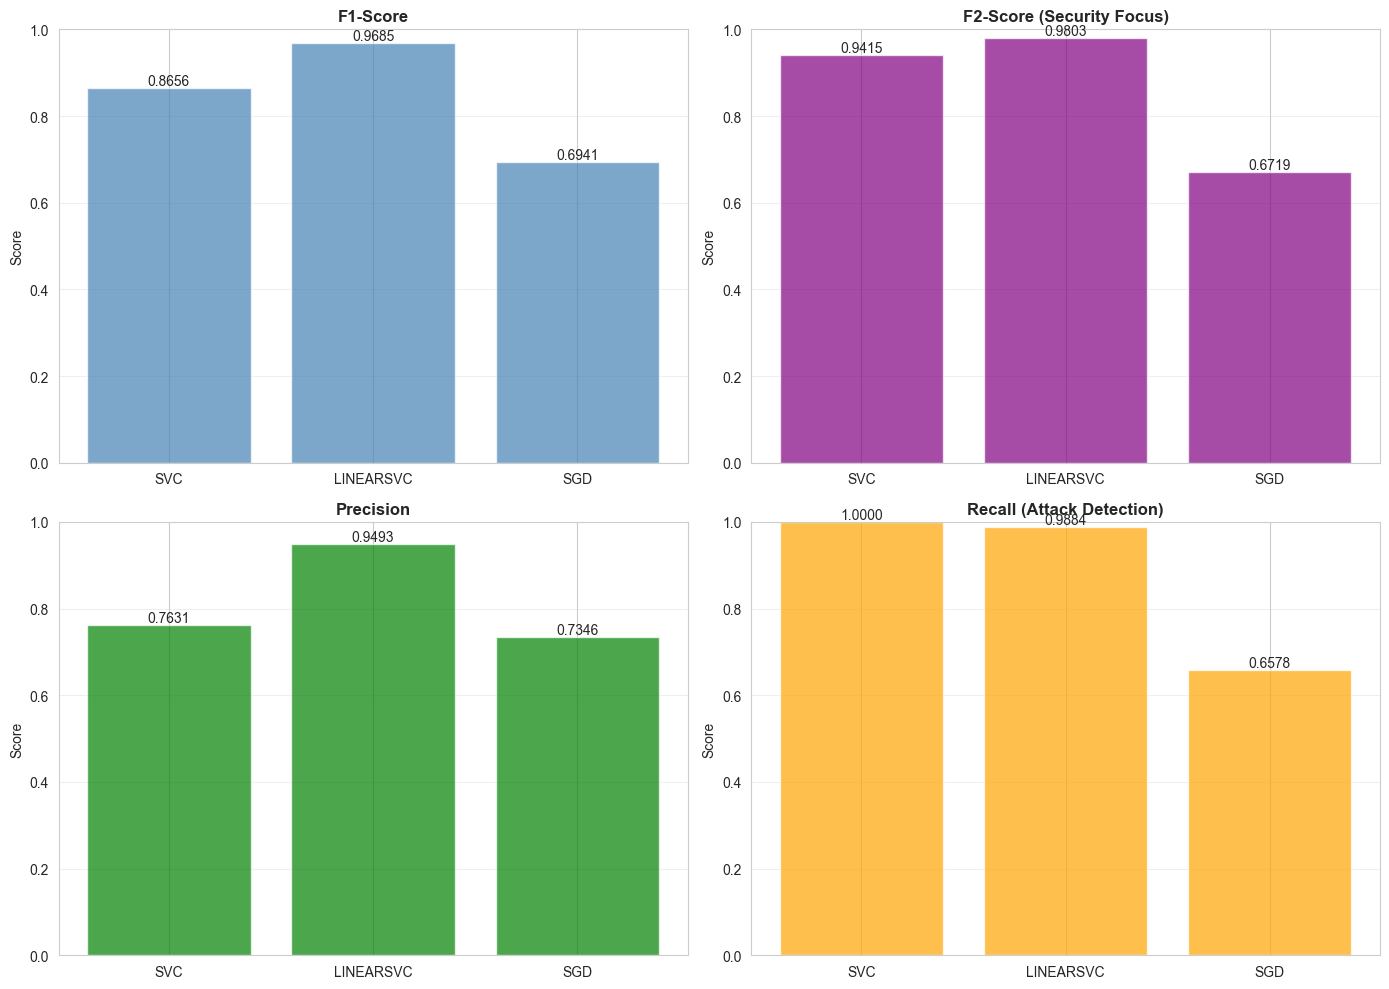

In [12]:
# Plot performance metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['f1', 'f2', 'precision', 'recall']
titles = ['F1-Score', 'F2-Score (Security Focus)', 'Precision', 'Recall (Attack Detection)']
colors = ['steelblue', 'purple', 'green', 'orange']

for ax, metric, title, color in zip(axes.flat, metrics_to_plot, titles, colors):
    values = [evaluation_results[mode][metric] for mode in TRAINING_MODES]
    bars = ax.bar([m.upper() for m in TRAINING_MODES], values, color=color, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 7.3 Visual Comparison - Resource Usage

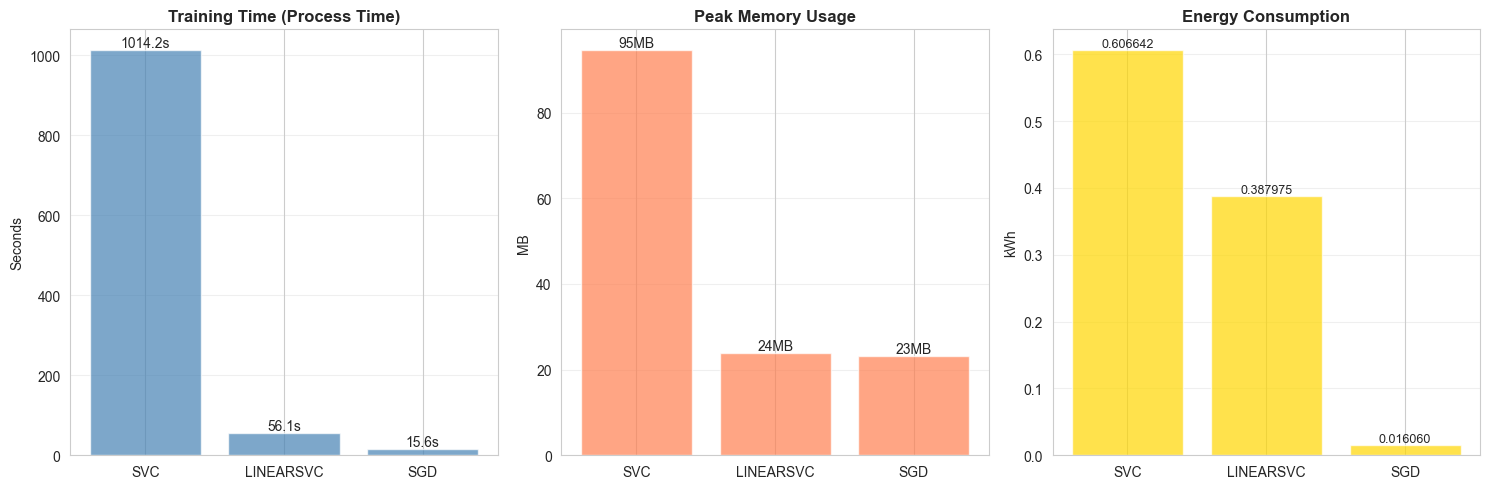


 Fastest training: SGD (15.58s)
 Lowest energy: SGD (0.016060 kWh)


In [13]:
if CONFIG['enable_monitoring']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Training Time
    times = [training_stats_all[mode]['process_time'] for mode in TRAINING_MODES]
    axes[0].bar([m.upper() for m in TRAINING_MODES], times, color='steelblue', alpha=0.7)
    axes[0].set_title('Training Time (Process Time)', fontweight='bold')
    axes[0].set_ylabel('Seconds')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(times):
        axes[0].text(i, v, f'{v:.1f}s', ha='center', va='bottom')
    
    # Peak Memory
    memory = [training_stats_all[mode]['peak_memory_mb'] for mode in TRAINING_MODES]
    axes[1].bar([m.upper() for m in TRAINING_MODES], memory, color='coral', alpha=0.7)
    axes[1].set_title('Peak Memory Usage', fontweight='bold')
    axes[1].set_ylabel('MB')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(memory):
        axes[1].text(i, v, f'{v:.0f}MB', ha='center', va='bottom')
    
    # Energy Consumption
    energy = [training_stats_all[mode]['energy_kwh'] for mode in TRAINING_MODES]
    axes[2].bar([m.upper() for m in TRAINING_MODES], energy, color='gold', alpha=0.7)
    axes[2].set_title('Energy Consumption', fontweight='bold')
    axes[2].set_ylabel('kWh')
    axes[2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(energy):
        axes[2].text(i, v, f'{v:.6f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Find most efficient
    fastest_mode = min(TRAINING_MODES, key=lambda m: training_stats_all[m]['process_time'])
    least_energy = min(TRAINING_MODES, key=lambda m: training_stats_all[m]['energy_kwh'])
    
    print(f"\n Fastest training: {fastest_mode.upper()} ({training_stats_all[fastest_mode]['process_time']:.2f}s)")
    print(f" Lowest energy: {least_energy.upper()} ({training_stats_all[least_energy]['energy_kwh']:.6f} kWh)")
else:
    print("Resource monitoring was disabled")

### 7.4 Confusion Matrices Comparison

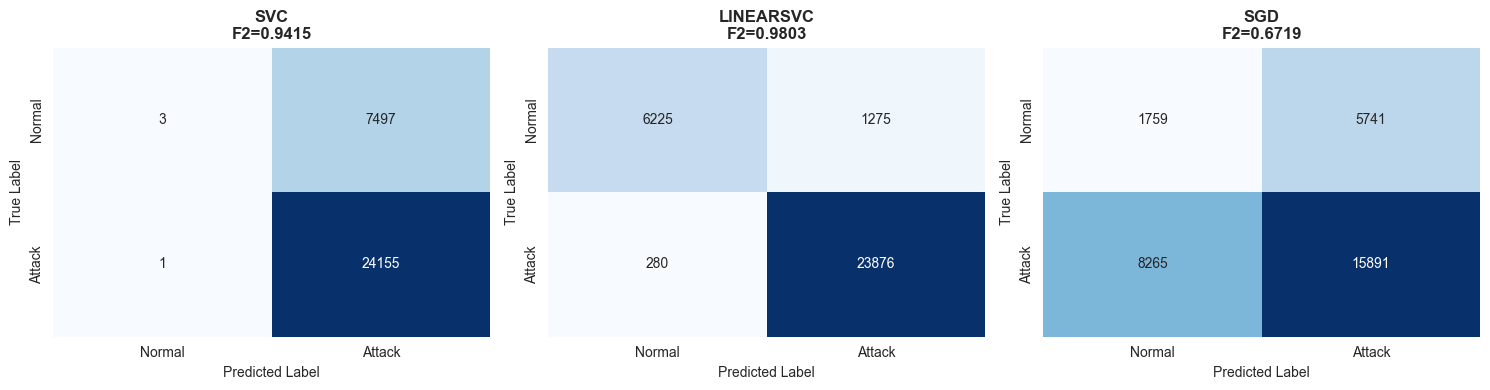


  Missed Attacks Comparison:
  SVC         :     1 / 24,156 (0.00%)
  LINEARSVC   :   280 / 24,156 (1.16%)
  SGD         : 8,265 / 24,156 (34.22%)


In [14]:
# Plot all confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mode in zip(axes, TRAINING_MODES):
    cm = evaluation_results[mode]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                cbar=False)
    ax.set_title(f'{mode.upper()}\nF2={evaluation_results[mode]["f2"]:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print missed attacks comparison
print("\n  Missed Attacks Comparison:")
for mode in TRAINING_MODES:
    cm = evaluation_results[mode]['confusion_matrix']
    fn = cm[1, 0]
    total_attacks = cm[1, 0] + cm[1, 1]
    print(f"  {mode.upper():12s}: {fn:5,} / {total_attacks:5,} ({fn/total_attacks*100:.2f}%)")

## 8. Save Models

**Note:** Only ONE preprocessing pipeline is saved (shared by all models)

In [15]:
if CONFIG['save_models']:
    print("\n" + "="*70)
    print("SAVING MODELS")
    print("="*70)
    
    # Save preprocessing pipeline ONCE (shared by all models)   
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    pipeline_file = f'shared_preprocessing_{timestamp}.pkl'
    joblib.dump(preprocessing_pipeline, pipeline_file)
    print(f"\n Shared preprocessing pipeline saved: {pipeline_file}")
    
    # Save each model separately
    print("\nSaving individual models:")
    for mode in TRAINING_MODES:
        model_file = f'{mode}_model_{timestamp}.pkl'
        joblib.dump(trained_models[mode], model_file)
        model_files[mode] = model_file
        print(f"   {mode.upper():12s}: {model_file}")
    
    print("\n" + "="*70)
    print("ALL MODELS SAVED")
    print("="*70)
    print(f"\nPreprocessing Pipeline (shared): {pipeline_file}")
    print("Model files:")
    for mode, file in model_files.items():
        print(f"  {mode.upper():12s}: {file}")
    
    print("\n Usage in inference notebook:")
    print("  import joblib")
    print(f"  pipeline = joblib.load('{pipeline_file}')")
    print(f"  model = joblib.load('{model_files[TRAINING_MODES[0]]}')  # Choose your model")
    
else:
    print("Model saving was disabled")
    pipeline_file = None
    model_files = {}


SAVING MODELS

 Shared preprocessing pipeline saved: shared_preprocessing_20260108_140619.pkl

Saving individual models:
   SVC         : svc_model_20260108_140619.pkl
   LINEARSVC   : linearsvc_model_20260108_140619.pkl
   SGD         : sgd_model_20260108_140619.pkl

ALL MODELS SAVED

Preprocessing Pipeline (shared): shared_preprocessing_20260108_140619.pkl
Model files:
  SVC         : svc_model_20260108_140619.pkl
  LINEARSVC   : linearsvc_model_20260108_140619.pkl
  SGD         : sgd_model_20260108_140619.pkl

 Usage in inference notebook:
  import joblib
  pipeline = joblib.load('shared_preprocessing_20260108_140619.pkl')
  model = joblib.load('svc_model_20260108_140619.pkl')  # Choose your model
